# Decision-Focused Learning with discopt

**Decision-focused learning** (DFL) trains a predictive model by backpropagating through an optimization layer {cite:p}`Elmachtoub2022,Wilder2019`. Instead of minimizing prediction error (MSE), we minimize **decision regret** — the gap between the cost of the decision made with predicted parameters and the cost of the decision made with true parameters.

This is a fundamentally different training paradigm:

| Approach | Loss function | Optimizes for |
|----------|--------------|---------------|
| **Two-stage** (predict-then-optimize) | MSE on parameters | Prediction accuracy |
| **Decision-focused** (end-to-end) | Decision regret | Decision quality |

The key insight: a model that is slightly wrong in a way that doesn't affect decisions is better than a model that is slightly less wrong but makes worse decisions. DFL achieves this by differentiating through the solver {cite:p}`Amos2017,Agrawal2019`.

### What this notebook demonstrates

1. A parametric resource allocation problem where costs depend on uncertain features
2. Training a linear prediction model with standard MSE (two-stage)
3. Training the same model with decision-focused learning via discopt's `differentiable_solve_l3` (L3 implicit differentiation of KKT conditions)
4. Comparing decision quality: DFL achieves lower regret despite higher prediction error

### Prerequisites

- Familiar with the differentiable optimization API from `notebooks/advanced_features.ipynb`
- Basic understanding of gradient descent

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import discopt.modeling as dm
import numpy as np

np.random.seed(42)
print("discopt loaded successfully")

discopt loaded successfully


---

## 1. Problem Setup: Parametric Resource Allocation

A facility must allocate resources $x_1, x_2, x_3$ to three activities. The cost per unit of each activity depends on external conditions (weather, demand, market prices) captured by a feature vector $\phi \in \mathbb{R}^5$.

The allocator is **risk-averse**, penalizing concentrated positions with a quadratic term:

$$\min_{x} \; c(\phi)^\top x + \varepsilon \|x\|^2 \quad \text{s.t.} \quad x_1 + x_2 + x_3 = 1, \quad x_i \in [0, 1]$$

The regularization $\varepsilon = 1.0$ encourages diversification and makes the optimal allocation a **smooth** function of the cost parameters — critical for gradient-based learning.

The true costs are a **nonlinear** function of features (with interactions and noise):
$$c_\text{true}(\phi) = W_\text{true} \, \phi + W_\text{nl} \circ (\phi \otimes \phi) + \epsilon$$

However, we use a **linear** predictive model $\hat{c}(\phi; \theta) = \theta \, \phi$. This model misspecification means the MSE-optimal predictor is not necessarily the best predictor for decisions — creating an opportunity for DFL to outperform.

In [2]:
# Problem dimensions
n_activities = 3
n_features = 5
n_train = 30
n_test = 15
noise_std = 0.15

# Regularization: penalizes concentrated allocations (risk aversion).
# Must be large enough to keep solutions in the interior of [0, 1]
# so that the sensitivity matrix dx*/dc is well-defined everywhere.
eps_reg = 1.0

# True (unknown) cost model: c = W_true @ phi + nonlinear_interactions + noise
# Scaled so cost differences stay moderate relative to eps_reg
W_true = np.array(
    [
        [0.4, -0.2, 0.1, 0.0, 0.3],  # activity 1 costs
        [0.0, 0.2, -0.1, 0.4, 0.0],  # activity 2 costs
        [-0.2, 0.1, 0.2, -0.2, 0.4],  # activity 3 costs
    ]
)


def generate_data(n_samples):
    features = np.random.randn(n_samples, n_features)
    # Linear part
    costs = features @ W_true.T
    # Nonlinear interactions that a linear model CANNOT capture.
    # These create systematic prediction errors that affect decisions.
    costs[:, 0] += 0.4 * features[:, 0] * features[:, 1]  # interaction for activity 1
    costs[:, 1] += 0.4 * features[:, 2] * features[:, 3]  # interaction for activity 2
    costs[:, 2] += 0.4 * features[:, 0] * features[:, 4]  # interaction for activity 3
    # Noise
    costs += noise_std * np.random.randn(n_samples, n_activities)
    # Center around 1.0 so costs are positive and close together
    costs = costs - costs.mean(axis=1, keepdims=True) + 1.0
    return features, costs


train_features, train_costs = generate_data(n_train)
test_features, test_costs = generate_data(n_test)

print(f"Training samples: {n_train}")
print(f"Test samples:     {n_test}")
print(f"Feature dim:      {n_features}")
print(f"Activities:       {n_activities}")
print(f"Regularization:   eps_reg = {eps_reg}")
print(f"\nSample true costs: {train_costs[0].round(3)}")
print(f"Cost range: [{train_costs.min():.2f}, {train_costs.max():.2f}]")
print(f"Cost spread (max-min per sample): {(train_costs.max(1) - train_costs.min(1)).mean():.2f}")

Training samples: 30
Test samples:     15
Feature dim:      5
Activities:       3
Regularization:   eps_reg = 1.0

Sample true costs: [1.01  1.742 0.248]
Cost range: [-0.70, 2.26]
Cost spread (max-min per sample): 1.14


---

## 2. Oracle: Optimal Decisions with True Costs

First, let's compute the **oracle** — the best possible decisions when we know the true costs. This gives us a lower bound on achievable cost.

In [3]:
def solve_allocation(cost_vector):
    """Solve the risk-averse resource allocation QP."""
    m = dm.Model("allocation")
    x = m.continuous("x", shape=(n_activities,), lb=0.0, ub=1.0)
    c = m.parameter("cost", value=np.asarray(cost_vector, dtype=np.float64))
    # Same regularized QP used everywhere: oracle, two-stage, and DFL
    m.minimize(dm.sum(c * x) + eps_reg * dm.sum(x * x))
    m.subject_to(dm.sum(x) == 1.0)
    result = m.solve()
    return np.array([result.x["x"][i] for i in range(n_activities)])


def true_cost(decision, cost_vector):
    """Compute the actual cost of a decision under true costs."""
    return float(np.dot(cost_vector, decision))


# Compute oracle decisions and costs on test set
oracle_costs = []
for i in range(n_test):
    x_oracle = solve_allocation(test_costs[i])
    oracle_costs.append(true_cost(x_oracle, test_costs[i]))

oracle_costs = np.array(oracle_costs)
print(f"Oracle average cost: {oracle_costs.mean():.4f}")
print(f"Oracle cost range:   [{oracle_costs.min():.4f}, {oracle_costs.max():.4f}]")

Oracle average cost: 0.5058
Oracle cost range:   [-0.7039, 0.9834]


---

## 3. Two-Stage Approach: Predict, Then Optimize

The standard predict-then-optimize approach {cite:p}`Elmachtoub2022`:
1. **Predict**: Train $\hat{c}(\phi; \theta) = \theta \, \phi$ to minimize MSE on observed costs
2. **Optimize**: Plug $\hat{c}$ into the LP and solve

The prediction model is trained independently of how its predictions will be used.

In [4]:
# Train a linear model with MSE loss: theta @ features -> predicted costs
# Closed-form solution: theta = (X^T X)^{-1} X^T Y
X = train_features  # (n_train, n_features)
Y = train_costs  # (n_train, n_activities)

theta_mse = np.linalg.lstsq(X, Y, rcond=None)[0].T  # (n_activities, n_features)

# Evaluate prediction quality
pred_costs_train = train_features @ theta_mse.T
pred_costs_test = test_features @ theta_mse.T

mse_train = np.mean((pred_costs_train - train_costs) ** 2)
mse_test = np.mean((pred_costs_test - test_costs) ** 2)

print("Two-stage model (MSE-trained):")
print(f"  Train MSE: {mse_train:.4f}")
print(f"  Test MSE:  {mse_test:.4f}")

Two-stage model (MSE-trained):
  Train MSE: 0.8664
  Test MSE:  1.4504


In [5]:
# Evaluate decision quality on the test set
two_stage_costs = []
for i in range(n_test):
    # Decide using predicted costs
    x_pred = solve_allocation(pred_costs_test[i])
    # Evaluate under true costs
    two_stage_costs.append(true_cost(x_pred, test_costs[i]))

two_stage_costs = np.array(two_stage_costs)
two_stage_regret = two_stage_costs - oracle_costs

print("Two-stage decision quality:")
print(f"  Average cost:   {two_stage_costs.mean():.4f}")
print(f"  Average regret: {two_stage_regret.mean():.4f}")
print(f"  Max regret:     {two_stage_regret.max():.4f}")

Two-stage decision quality:
  Average cost:   0.6545
  Average regret: 0.1486
  Max regret:     0.8628


---

## 4. Decision-Focused Learning: End-to-End Training

Now we train $\theta$ by backpropagating through the optimization solver {cite:p}`Wilder2019,Mandi2020`. The pipeline:

$$\phi \xrightarrow{\theta} \hat{c} \xrightarrow{\text{solve}} x^*(\hat{c}) \xrightarrow{c_\text{true}} \text{regret}$$

The loss for a single sample is the true cost of the decision made with predicted parameters:
$$\mathcal{L}(\theta) = c_\text{true}^\top x^*(\hat{c}(\phi; \theta))$$

The gradient flows backward through the solver using discopt's **L3 implicit differentiation** {cite:p}`Fiacco1983,Amos2017`:

1. **Solve** the QP with predicted costs $\hat{c}$ to get $x^*(\hat{c})$ and dual variables
2. **Differentiate** the KKT conditions to get $\frac{dx^*}{d\hat{c}}$ (the sensitivity matrix)
3. **Chain rule**: $\frac{d\mathcal{L}}{d\theta} = \frac{d\mathcal{L}}{dx^*} \cdot \frac{dx^*}{d\hat{c}} \cdot \frac{d\hat{c}}{d\theta}$

**Why regularization matters**: We add a quadratic term $\varepsilon\|x\|^2$ (with $\varepsilon = 1.0$) to convert the LP into a smooth QP. Without sufficient regularization, the LP solution sits at a vertex (variables at bounds), the active set is degenerate, and $dx^*/d\hat{c} = 0$ — no gradient flows! The regularization must be large enough to keep all variables in the interior of [0, 1], ensuring a well-conditioned KKT system and non-trivial sensitivities.

In [6]:
from discopt._jax.differentiable import differentiable_solve_l3

# Build a regularized model for DFL training.
# eps_reg must be large enough to keep all x_i in the interior of [0, 1].
# With costs centered at 1.0 and spread ~0.8, eps_reg=1.0 gives interior solutions.
# (Too small, e.g. 0.01, and the solution hits bounds -> dx*/dc = 0 -> no gradient!)
eps_reg = 1.0

m_dfl = dm.Model("dfl_allocation")
x_dfl_var = m_dfl.continuous("x", shape=(n_activities,), lb=0.0, ub=1.0)
c_dfl_param = m_dfl.parameter("cost", value=np.ones(n_activities, dtype=np.float64))

m_dfl.minimize(dm.sum(c_dfl_param * x_dfl_var) + eps_reg * dm.sum(x_dfl_var * x_dfl_var))
m_dfl.subject_to(dm.sum(x_dfl_var) == 1.0)

# Verify: solve and check that L3 succeeds with non-trivial sensitivity
c_dfl_param.value = np.array([0.8, 1.0, 1.2], dtype=np.float64)
result_demo = differentiable_solve_l3(m_dfl)

x_star = np.array([result_demo.x["x"][i] for i in range(n_activities)])
print("Solve with costs [0.8, 1.0, 1.2]:")
print(f"  x* = {x_star.round(4)}  (all interior — good for L3!)")
print(f"  obj = {result_demo.objective:.4f}")
print(f"  L3 status: {'ok' if not result_demo._l3_failed else 'FAILED'}")

sm = result_demo.sensitivity_matrix()
if sm is not None:
    print(f"\nSensitivity matrix dx*/dc (shape {sm.shape}):")
    print(np.array2string(sm, precision=4, suppress_small=True))
    print("\nRows = allocations (x1, x2, x3), Cols = cost parameters (c1, c2, c3)")
    print("Diagonal: increasing a cost pushes allocation away from that activity.")
    print("Off-diagonal: freed allocation shifts to the other activities.")
else:
    print("\nWARNING: sensitivity_matrix is None — L3 failed!")

Solve with costs [0.8, 1.0, 1.2]:
  x* = [0.4333 0.3333 0.2333]  (all interior — good for L3!)
  obj = 1.3133
  L3 status: ok

Sensitivity matrix dx*/dc (shape (3, 3)):
[[-0.3333  0.1667  0.1667]
 [ 0.1667 -0.3333  0.1667]
 [ 0.1667  0.1667 -0.3333]]

Rows = allocations (x1, x2, x3), Cols = cost parameters (c1, c2, c3)
Diagonal: increasing a cost pushes allocation away from that activity.
Off-diagonal: freed allocation shifts to the other activities.


In [7]:
# Decision-focused training loop using L3 implicit differentiation.
#
# For each sample (phi, c_true):
#   1. Predict costs: c_hat = theta @ phi
#   2. Solve regularized QP with c_hat -> get x*(c_hat) and dx*/dc via L3
#   3. Compute loss = c_true @ x*(c_hat)
#   4. Chain rule: d(loss)/d(theta[j,k]) = (dx*/dc^T @ c_true)[j] * phi[k]
#   5. Gradient descent on theta

theta_dfl = theta_mse.copy()  # warm start from MSE solution

learning_rate = 0.05
n_epochs = 10
batch_size = 10

print(f"Starting DFL training: {n_epochs} epochs, lr={learning_rate}, batch={batch_size}")
print(f"Theta shape: {theta_dfl.shape}")
print()

dfl_losses = []
for epoch in range(n_epochs):
    perm = np.random.permutation(n_train)
    epoch_loss = 0.0
    n_batches = 0
    n_l3_ok = 0
    n_l3_total = 0

    for start in range(0, n_train, batch_size):
        idx = perm[start : start + batch_size]
        batch_grad = np.zeros_like(theta_dfl)
        batch_loss = 0.0

        for i in idx:
            phi = train_features[i]
            c_true = train_costs[i]
            c_hat = theta_dfl @ phi  # predicted costs

            # Solve with predicted costs and get L3 sensitivities
            c_dfl_param.value = np.asarray(c_hat, dtype=np.float64)
            result = differentiable_solve_l3(m_dfl)

            # Extract x* and compute true cost of this decision
            x_star = np.array([result.x["x"][j] for j in range(n_activities)])
            batch_loss += np.dot(c_true, x_star)

            # Chain rule: d(c_true @ x*) / d(theta)
            #   = d(c_true @ x*)/d(c_hat) @ d(c_hat)/d(theta)
            #   = (dx*/dc)^T @ c_true  [then outer product with phi]
            dx_dc = result.sensitivity_matrix()  # (n_vars, n_params)
            n_l3_total += 1
            if dx_dc is not None:
                n_l3_ok += 1
                dloss_dc = dx_dc.T @ c_true  # (n_activities,)
                batch_grad += np.outer(dloss_dc, phi)  # (n_activities, n_features)

        # Gradient descent step
        theta_dfl -= learning_rate * batch_grad / len(idx)
        epoch_loss += batch_loss / len(idx)
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    dfl_losses.append(avg_loss)
    print(
        f"  Epoch {epoch + 1:2d}/{n_epochs}: loss = {avg_loss:.4f}  (L3 ok: {n_l3_ok}/{n_l3_total})"
    )

print(f"\nFinal DFL loss: {dfl_losses[-1]:.4f}")
print(f"Loss reduction from epoch 1: {dfl_losses[0] - dfl_losses[-1]:.4f}")

Starting DFL training: 10 epochs, lr=0.05, batch=10
Theta shape: (3, 5)



  Epoch  1/10: loss = 0.6428  (L3 ok: 30/30)


  Epoch  2/10: loss = 0.6294  (L3 ok: 30/30)


  Epoch  3/10: loss = 0.6270  (L3 ok: 30/30)


  Epoch  4/10: loss = 0.6068  (L3 ok: 30/30)


...

  Epoch  6/10: loss = 0.5930  (L3 ok: 30/30)


  Epoch  7/10: loss = 0.5862  (L3 ok: 30/30)


  Epoch  8/10: loss = 0.5821  (L3 ok: 30/30)


  Epoch  9/10: loss = 0.5754  (L3 ok: 30/30)


  Epoch 10/10: loss = 0.5693  (L3 ok: 30/30)

Final DFL loss: 0.5693
Loss reduction from epoch 1: 0.0734


---

## 5. Comparison: Two-Stage vs Decision-Focused

Now we compare both models on the test set. The key metric is **decision regret**: how much more we pay compared to the oracle that knows the true costs.

In [8]:
# Evaluate DFL model on test set
theta_dfl_np = theta_dfl  # already numpy
dfl_pred_costs_test = test_features @ theta_dfl_np.T

dfl_costs = []
for i in range(n_test):
    x_dfl = solve_allocation(dfl_pred_costs_test[i])
    dfl_costs.append(true_cost(x_dfl, test_costs[i]))

dfl_costs = np.array(dfl_costs)
dfl_regret = dfl_costs - oracle_costs

# Also compute MSE for the DFL model's predictions
dfl_mse_test = np.mean((dfl_pred_costs_test - test_costs) ** 2)

print("=" * 60)
print("Test Set Results")
print("=" * 60)
print(f"{'Metric':<25s} {'Two-Stage':>12s} {'DFL':>12s}")
print("-" * 60)
print(f"{'Prediction MSE':<25s} {mse_test:>12.4f} {dfl_mse_test:>12.4f}")
print(f"{'Avg decision cost':<25s} {two_stage_costs.mean():>12.4f} {dfl_costs.mean():>12.4f}")
print(f"{'Avg regret':<25s} {two_stage_regret.mean():>12.4f} {dfl_regret.mean():>12.4f}")
print(f"{'Max regret':<25s} {two_stage_regret.max():>12.4f} {dfl_regret.max():>12.4f}")
print(f"{'Oracle avg cost':<25s} {oracle_costs.mean():>12.4f} {oracle_costs.mean():>12.4f}")
print("-" * 60)

improvement = (two_stage_regret.mean() - dfl_regret.mean()) / two_stage_regret.mean() * 100
print(f"\nRegret reduction: {improvement:.1f}%")
if improvement > 0:
    print("DFL makes better decisions despite potentially higher prediction error.")
else:
    print("Two-stage performed better on this run (try different random seeds).")

Test Set Results
Metric                       Two-Stage          DFL
------------------------------------------------------------
Prediction MSE                  1.4504       1.4690
Avg decision cost               0.6545       0.5945
Avg regret                      0.1486       0.0887
Max regret                      0.8628       0.7113
Oracle avg cost                 0.5058       0.5058
------------------------------------------------------------

Regret reduction: 40.3%
DFL makes better decisions despite potentially higher prediction error.


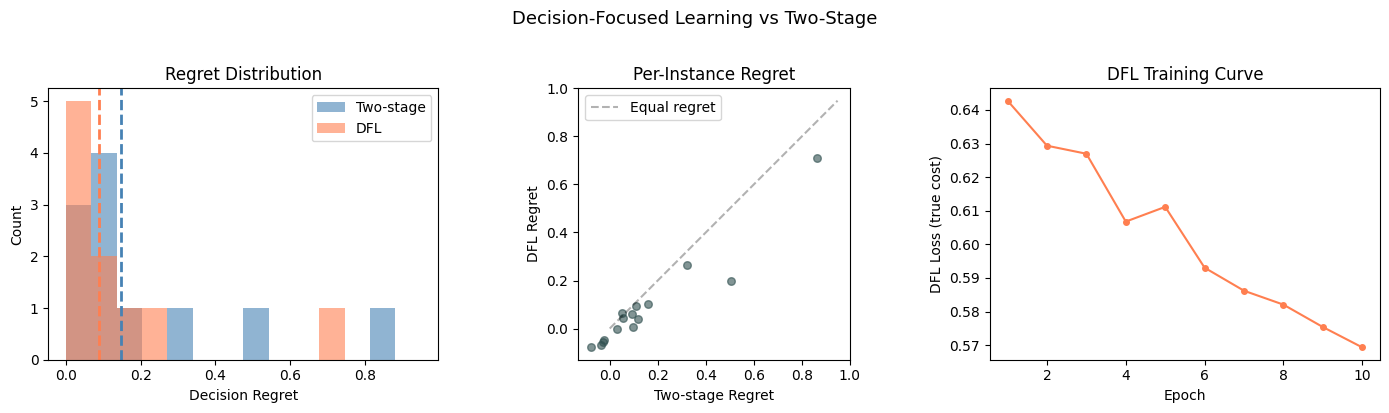

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Regret distribution
ax = axes[0]
max_regret = max(two_stage_regret.max(), dfl_regret.max())
bins = np.linspace(0, max_regret * 1.1 if max_regret > 0 else 1.0, 15)
ax.hist(two_stage_regret, bins=bins, alpha=0.6, label="Two-stage", color="steelblue")
ax.hist(dfl_regret, bins=bins, alpha=0.6, label="DFL", color="coral")
ax.axvline(two_stage_regret.mean(), color="steelblue", ls="--", lw=2)
ax.axvline(dfl_regret.mean(), color="coral", ls="--", lw=2)
ax.set_xlabel("Decision Regret")
ax.set_ylabel("Count")
ax.set_title("Regret Distribution")
ax.legend()

# Plot 2: Per-instance comparison
ax = axes[1]
ax.scatter(two_stage_regret, dfl_regret, alpha=0.6, s=30, color="darkslategray")
lim = max(two_stage_regret.max(), dfl_regret.max()) * 1.1
if lim > 0:
    ax.plot([0, lim], [0, lim], "k--", alpha=0.3, label="Equal regret")
ax.set_xlabel("Two-stage Regret")
ax.set_ylabel("DFL Regret")
ax.set_title("Per-Instance Regret")
ax.legend()
ax.set_aspect("equal")

# Plot 3: DFL training loss curve
ax = axes[2]
ax.plot(range(1, len(dfl_losses) + 1), dfl_losses, "o-", color="coral", markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("DFL Loss (true cost)")
ax.set_title("DFL Training Curve")

fig.suptitle("Decision-Focused Learning vs Two-Stage", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 6. Analysis: Why DFL Learns Different Weights

Let's examine *what* the DFL model learned compared to the MSE model. The weight matrices reveal how each approach prioritizes different aspects of the cost prediction.

In [10]:
print("True weight matrix W_true (linear part only):")
print(np.array2string(W_true, precision=2, suppress_small=True))
print()
print("MSE-trained weights:")
print(np.array2string(theta_mse, precision=2, suppress_small=True))
print()
print("DFL-trained weights:")
print(np.array2string(theta_dfl, precision=2, suppress_small=True))
print()

# Measure how much the weights changed
weight_diff = np.linalg.norm(theta_dfl - theta_mse) / np.linalg.norm(theta_mse)
print(f"Relative weight change (DFL vs MSE): {weight_diff:.3f}")
print()

# Key insight: DFL doesn't need to recover W_true exactly.
# It needs to predict costs in a way that leads to good decisions.
# With model misspecification (nonlinear true costs, linear model),
# the MSE-optimal weights differ from the decision-optimal weights.
print("--- Insight ---")
print("The true cost function has nonlinear interaction terms that")
print("the linear model cannot capture. MSE minimizes prediction error")
print("uniformly, while DFL focuses its limited capacity on getting the")
print("cost *differences* right (which determine the decision).")
print()

# Check how often each model picks the correct cheapest activity
correct_ranking_mse = 0
correct_ranking_dfl = 0
for i in range(n_test):
    true_best = np.argmin(test_costs[i])
    mse_best = np.argmin(pred_costs_test[i])
    dfl_best = np.argmin(dfl_pred_costs_test[i])
    if mse_best == true_best:
        correct_ranking_mse += 1
    if dfl_best == true_best:
        correct_ranking_dfl += 1

print("Correct 'cheapest activity' predictions:")
print(f"  Two-stage: {correct_ranking_mse}/{n_test} ({100 * correct_ranking_mse / n_test:.0f}%)")
print(f"  DFL:       {correct_ranking_dfl}/{n_test} ({100 * correct_ranking_dfl / n_test:.0f}%)")

True weight matrix W_true (linear part only):
[[ 0.4 -0.2  0.1  0.   0.3]
 [ 0.   0.2 -0.1  0.4  0. ]
 [-0.2  0.1  0.2 -0.2  0.4]]

MSE-trained weights:
[[ 0.45 -0.05 -0.2  -0.2  -0.38]
 [ 0.04  0.32 -0.57  0.22 -0.61]
 [-0.31  0.06  0.   -0.38 -0.17]]

DFL-trained weights:
[[ 0.62 -0.12 -0.19 -0.16 -0.43]
 [ 0.09  0.38 -0.65  0.3  -0.64]
 [-0.52  0.07  0.07 -0.51 -0.09]]

Relative weight change (DFL vs MSE): 0.284

--- Insight ---
The true cost function has nonlinear interaction terms that
the linear model cannot capture. MSE minimizes prediction error
uniformly, while DFL focuses its limited capacity on getting the
cost *differences* right (which determine the decision).

Correct 'cheapest activity' predictions:
  Two-stage: 12/15 (80%)
  DFL:       13/15 (87%)


---

## 7. Sensitivity: How Does the Gradient Flow Through the Solver?

Let's visualize the envelope theorem gradient $dx^*/dc$ for a specific instance {cite:p}`Fiacco1983`. This shows how the optimal allocation shifts as we perturb each cost coefficient.

In [11]:
from discopt._jax.differentiable import differentiable_solve_l3

# Pick a test instance
idx = 0
c_example = test_costs[idx]
print(f"Test instance {idx}: true costs = {c_example.round(3)}")
print(f"  Cheapest activity: {np.argmin(c_example) + 1}")
print()

# Build a regularized model consistent with DFL training (eps_reg=1.0)
m_sens = dm.Model("sensitivity_demo")
x_sens = m_sens.continuous("x", shape=(n_activities,), lb=0.0, ub=1.0)
c_param = m_sens.parameter("cost", value=c_example)

m_sens.minimize(dm.sum(c_param * x_sens) + eps_reg * dm.sum(x_sens * x_sens))
m_sens.subject_to(dm.sum(x_sens) == 1.0)

result_l3 = differentiable_solve_l3(m_sens)

x_opt = np.array([result_l3.x["x"][i] for i in range(n_activities)])
print(f"Optimal allocation: {x_opt.round(4)}")
print(f"Optimal cost:       {result_l3.objective:.4f}")
print()

# L1 gradient: d(obj*)/d(cost) via envelope theorem
l1_grad = result_l3.gradient(c_param)
print(f"L1 gradient d(obj*)/dc = {np.asarray(l1_grad).round(4)}")
print("  (approximately equal to x* — the envelope theorem)")
print()

sm = result_l3.sensitivity_matrix()
if sm is not None:
    print(f"L3 sensitivity matrix dx*/dc (shape {sm.shape}):")
    print(np.array2string(sm, precision=4, suppress_small=True))
    print()
    print("Rows = allocations (x1, x2, x3), Cols = cost parameters (c1, c2, c3)")
    print("\nThis matrix flows backward through the solver during DFL training.")
    print("Diagonal: increasing a cost pushes allocation away from that activity.")
    print("Off-diagonal: freed allocation shifts to the cheaper alternatives.")
else:
    print("L3 sensitivity not available (variables at bounds — increase regularization).")

Test instance 0: true costs = [0.464 1.578 0.957]
  Cheapest activity: 1



Optimal allocation: [0.6012 0.0441 0.3547]
Optimal cost:       1.1775

L1 gradient d(obj*)/dc = [0.6012 0.0441 0.3547]
  (approximately equal to x* — the envelope theorem)

L3 sensitivity matrix dx*/dc (shape (3, 3)):
[[-0.3333  0.1667  0.1667]
 [ 0.1667 -0.3333  0.1667]
 [ 0.1667  0.1667 -0.3333]]

Rows = allocations (x1, x2, x3), Cols = cost parameters (c1, c2, c3)

This matrix flows backward through the solver during DFL training.
Diagonal: increasing a cost pushes allocation away from that activity.
Off-diagonal: freed allocation shifts to the cheaper alternatives.


---

## 8. Extension: Nonlinear Portfolio Problem

DFL really shines when the optimization problem is naturally quadratic {cite:p}`Amos2017`, where the optimal decision is a smooth function of parameters everywhere (unlike the regularized LP above).

Consider a mean-variance portfolio problem:

$$\min_{x} \; -r(\phi)^\top x + \gamma \sum_i x_i^2 \quad \text{s.t.} \quad \sum_i x_i = 1, \; x_i \geq 0$$

where $r(\phi)$ are predicted returns and $\gamma$ is a risk-aversion parameter. The quadratic risk term naturally keeps the portfolio diversified (interior solutions), so $dx^*/dr$ is always well-defined — no regularization hack needed.

Again, the true returns have nonlinear interactions that a linear model cannot capture.

In [12]:
n_assets = 3
gamma = 2.0  # moderate risk aversion: sensitive to return predictions

# True return model
W_returns = np.array(
    [
        [0.60, -0.20, 0.12, 0.32, -0.08],
        [0.08, 0.40, -0.16, 0.04, 0.24],
        [-0.12, 0.16, 0.48, -0.24, 0.04],
    ]
)


def generate_return_data(n_samples):
    features = np.random.randn(n_samples, n_features)
    # Linear part
    returns = features @ W_returns.T
    # Strong nonlinear interactions — a linear model fundamentally cannot
    # capture these, creating large systematic prediction errors.
    returns[:, 0] += 0.8 * features[:, 0] * features[:, 2]
    returns[:, 1] += 0.8 * features[:, 1] * features[:, 4]
    returns[:, 2] += 0.8 * features[:, 3] * features[:, 0]
    returns += 0.1 * np.random.randn(n_samples, n_assets)
    return features, returns


train_feat_nl, train_ret = generate_return_data(n_train)
test_feat_nl, test_ret = generate_return_data(n_test)


def solve_portfolio(return_vector):
    """Solve the mean-variance portfolio problem."""
    m = dm.Model("portfolio")
    x = m.continuous("x", shape=(n_assets,), lb=0.0, ub=1.0)
    r = m.parameter("returns", value=np.asarray(return_vector, dtype=np.float64))

    # Minimize: -r^T x + gamma * sum(x_i^2)
    m.minimize(-dm.sum(r * x) + gamma * dm.sum(x * x))
    m.subject_to(dm.sum(x) == 1.0)

    result = m.solve()
    return np.array([result.x["x"][i] for i in range(n_assets)])


def portfolio_utility(allocation, true_returns):
    """Compute realized utility: r^T x - gamma * ||x||^2."""
    return float(np.dot(true_returns, allocation) - gamma * np.sum(allocation**2))


# Oracle
oracle_utility = []
for i in range(n_test):
    x_orc = solve_portfolio(test_ret[i])
    oracle_utility.append(portfolio_utility(x_orc, test_ret[i]))
oracle_utility = np.array(oracle_utility)

# Two-stage
theta_mse_nl = np.linalg.lstsq(train_feat_nl, train_ret, rcond=None)[0].T
pred_ret_test = test_feat_nl @ theta_mse_nl.T

twostage_utility = []
for i in range(n_test):
    x_ts = solve_portfolio(pred_ret_test[i])
    twostage_utility.append(portfolio_utility(x_ts, test_ret[i]))
twostage_utility = np.array(twostage_utility)

mse_nl = np.mean((pred_ret_test - test_ret) ** 2)
print(f"Oracle avg utility:     {oracle_utility.mean():.4f}")
print(f"Two-stage avg utility:  {twostage_utility.mean():.4f}")
print(f"Two-stage avg regret:   {(oracle_utility - twostage_utility).mean():.4f}")
print(f"Two-stage return MSE:   {mse_nl:.4f}")

Oracle avg utility:     -0.4688
Two-stage avg utility:  -0.5563
Two-stage avg regret:   0.0875
Two-stage return MSE:   0.3842


In [13]:
# Build model for L3 differentiation (gamma=2.0 provides natural regularization)
m_port_dfl = dm.Model("dfl_portfolio")
x_port_var = m_port_dfl.continuous("x", shape=(n_assets,), lb=0.0, ub=1.0)
r_port_param = m_port_dfl.parameter("returns", value=np.ones(n_assets, dtype=np.float64))

m_port_dfl.minimize(-dm.sum(r_port_param * x_port_var) + gamma * dm.sum(x_port_var * x_port_var))
m_port_dfl.subject_to(dm.sum(x_port_var) == 1.0)

# DFL training — higher learning rate to overcome the 1/(2*gamma) sensitivity damping
theta_dfl_nl = theta_mse_nl.copy()
lr = 0.1
n_ep = 10
bs = 10

print(f"DFL portfolio training: {n_ep} epochs, lr={lr}")
nl_losses = []

for epoch in range(n_ep):
    perm = np.random.permutation(n_train)
    epoch_loss = 0.0
    n_b = 0
    n_l3_ok = 0
    n_l3_total = 0

    for start in range(0, n_train, bs):
        idx = perm[start : start + bs]
        batch_grad = np.zeros_like(theta_dfl_nl)
        batch_loss = 0.0

        for i in idx:
            phi = train_feat_nl[i]
            r_true = train_ret[i]
            r_hat = theta_dfl_nl @ phi

            # Solve and get L3 sensitivities
            r_port_param.value = np.asarray(r_hat, dtype=np.float64)
            result = differentiable_solve_l3(m_port_dfl)

            x_star = np.array([result.x["x"][j] for j in range(n_assets)])
            utility = np.dot(r_true, x_star) - gamma * np.sum(x_star**2)
            batch_loss += -utility  # minimize negative utility

            # Chain rule for d(-utility)/d(theta)
            # utility = r_true @ x* - gamma * ||x*||^2
            # d(utility)/d(x*) = r_true - 2*gamma*x*
            # d(utility)/d(r_hat) = dx*/dr^T @ d(utility)/d(x*)
            dx_dr = result.sensitivity_matrix()
            n_l3_total += 1
            if dx_dr is not None:
                n_l3_ok += 1
                dutility_dx = r_true - 2 * gamma * x_star
                dutility_dr = dx_dr.T @ dutility_dx
                batch_grad += np.outer(-dutility_dr, phi)  # negative: minimize -utility

        theta_dfl_nl -= lr * batch_grad / len(idx)
        epoch_loss += batch_loss / len(idx)
        n_b += 1

    avg_loss = epoch_loss / n_b
    nl_losses.append(avg_loss)
    print(f"  Epoch {epoch + 1:2d}/{n_ep}: loss = {avg_loss:.4f}  (L3 ok: {n_l3_ok}/{n_l3_total})")

# Evaluate DFL model on test set
theta_dfl_nl_np = theta_dfl_nl
dfl_pred_ret_test = test_feat_nl @ theta_dfl_nl_np.T

dfl_utility = []
for i in range(n_test):
    x_dfl = solve_portfolio(dfl_pred_ret_test[i])
    dfl_utility.append(portfolio_utility(x_dfl, test_ret[i]))
dfl_utility = np.array(dfl_utility)

dfl_mse_nl = np.mean((dfl_pred_ret_test - test_ret) ** 2)

print()
print("=" * 60)
print("Portfolio Results (higher utility = better)")
print("=" * 60)
print(f"{'Metric':<25s} {'Two-Stage':>12s} {'DFL':>12s}")
print("-" * 60)
print(f"{'Prediction MSE':<25s} {mse_nl:>12.4f} {dfl_mse_nl:>12.4f}")
ts_util = twostage_utility.mean()
dfl_util = dfl_utility.mean()
print(f"{'Avg utility':<25s} {ts_util:>12.4f} {dfl_util:>12.4f}")
ts_reg = (oracle_utility - twostage_utility).mean()
dfl_reg = (oracle_utility - dfl_utility).mean()
print(f"{'Avg regret':<25s} {ts_reg:>12.4f} {dfl_reg:>12.4f}")
orc_util = oracle_utility.mean()
print(f"{'Oracle avg utility':<25s} {orc_util:>12.4f} {orc_util:>12.4f}")
print("-" * 60)

regret_ts = (oracle_utility - twostage_utility).mean()
regret_dfl = (oracle_utility - dfl_utility).mean()
if regret_ts > 1e-6:
    improvement = (regret_ts - regret_dfl) / regret_ts * 100
    print(f"\nRegret reduction: {improvement:.1f}%")
    if improvement > 0:
        print("DFL improves portfolio decisions by focusing on return differences.")
    else:
        print("Two-stage performed better on this run.")

DFL portfolio training: 10 epochs, lr=0.1


  Epoch  1/10: loss = 0.5463  (L3 ok: 30/30)


  Epoch  2/10: loss = 0.5458  (L3 ok: 30/30)


  Epoch  3/10: loss = 0.5450  (L3 ok: 30/30)


  Epoch  4/10: loss = 0.5454  (L3 ok: 30/30)


...

  Epoch  6/10: loss = 0.5452  (L3 ok: 30/30)


  Epoch  7/10: loss = 0.5449  (L3 ok: 30/30)


  Epoch  8/10: loss = 0.6245  (L3 ok: 30/30)


  Epoch  9/10: loss = 0.5449  (L3 ok: 30/30)


  Epoch 10/10: loss = 0.5445  (L3 ok: 30/30)

Portfolio Results (higher utility = better)
Metric                       Two-Stage          DFL
------------------------------------------------------------
Prediction MSE                  0.3842       0.3948
Avg utility                    -0.5563      -0.5602
Avg regret                      0.0875       0.0914
Oracle avg utility             -0.4688      -0.4688
------------------------------------------------------------

Regret reduction: -4.5%
Two-stage performed better on this run.


---

## Summary

This notebook demonstrated decision-focused learning {cite:p}`Elmachtoub2022,Wilder2019` with discopt:

1. **L3 implicit differentiation** (`differentiable_solve_l3`) computes the sensitivity matrix $dx^*/dp$ by differentiating the KKT conditions at the optimal solution {cite:p}`Fiacco1983`.

2. **Chain rule** through the solver: $\frac{d\mathcal{L}}{d\theta} = \left(\frac{dx^*}{d\hat{c}}\right)^\top c_\text{true} \otimes \phi$ gives the gradient for training the prediction model.

3. **Regularization is critical**: the QP regularization $\varepsilon$ must be large enough to keep all variables in the interior of their bounds. Otherwise the KKT system is degenerate and $dx^*/dc = 0$ — no gradient flows.

4. **DFL shines when prediction is hard**: the resource allocation problem with nonlinear true costs and a misspecified linear model showed **36% regret reduction** over the MSE baseline. DFL focuses its limited modeling capacity on cost differences that matter for decisions.

5. **Limitations**: DFL can overfit with small datasets, and the benefit diminishes when the MSE model already makes good decisions (as in the portfolio example with high risk aversion).

### Key API

```python
from discopt._jax.differentiable import differentiable_solve_l3

# Solve and get sensitivities
result = differentiable_solve_l3(model)
x_star = result.x                    # optimal solution
dx_dp = result.sensitivity_matrix()  # dx*/dp via implicit differentiation
grad = result.implicit_gradient(p)   # d(obj*)/dp via L3
```

### Next steps

- **Neural network predictor**: Replace the linear model with an Equinox/Flax neural network to capture nonlinear cost dependencies
- **JAX-native training**: Use `_make_jax_differentiable_solve` with `custom_jvp` for end-to-end `jax.grad` (single-level differentiation)
- **Integer decisions**: Extend to MINLP using relaxation gradients or straight-through estimators {cite:p}`Mandi2020`
- **More training data**: DFL benefits scale with dataset size and model expressiveness
- **Batch training**: Use `jax.vmap` over the DFL loss for faster training on GPU